## 随机森林

In [1]:
%matplotlib inline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_wine

In [2]:
wine = load_wine()

1. 实例化
2. 将训练集代入模型训练，使用接口`fit`
3. 将测试集导入模型，获取希望的结果`score`

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
Xtrain, Xtest, Ytrain, Ytest = train_test_split(wine.data, wine.target, train_size=0.7)

In [5]:
print(Xtrain.shape, Xtest.shape)

(124, 13) (54, 13)


In [10]:
clf = DecisionTreeClassifier(random_state=42)
rfc = RandomForestClassifier(random_state=42)

clf.fit(Xtrain, Ytrain)
rfc.fit(Xtrain, Ytrain)

score_c = clf.score(Xtest, Ytest)
score_r = rfc.score(Xtest, Ytest)

print(f"Decision Tree:{score_c}")
print(f"Random Forest:{score_r}")

Decision Tree:0.8148148148148148
Random Forest:0.9629629629629629


In [6]:
# 交叉验证
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

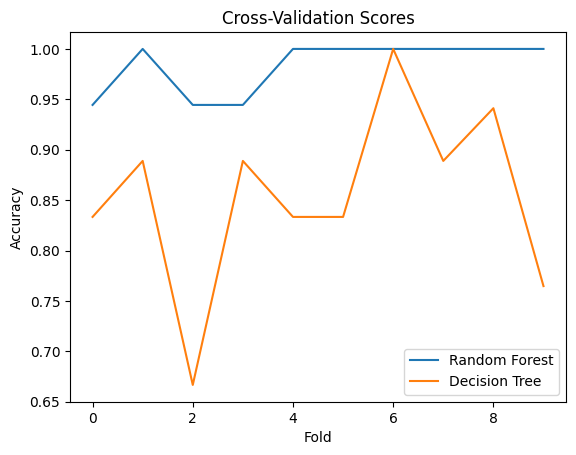

In [12]:
rfc = RandomForestClassifier(n_estimators=25)
rfc_s = cross_val_score(rfc, wine.data, wine.target, cv=10)

clf = DecisionTreeClassifier()
clf_s = cross_val_score(clf, wine.data, wine.target, cv=10)

plt.plot(rfc_s, label="Random Forest")
plt.plot(clf_s, label="Decision Tree")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Cross-Validation Scores")
plt.legend()
plt.show()


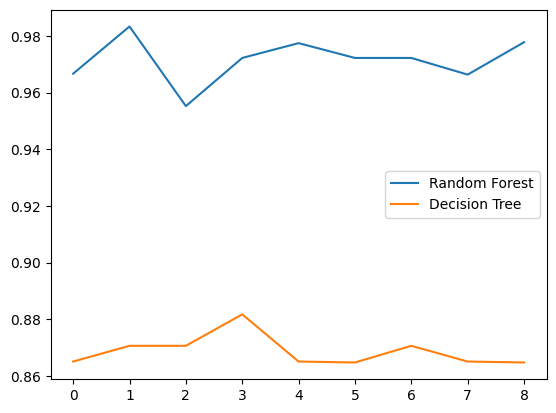

In [17]:
clf_l = []
rfc_l = []

for i in range(1, 10):
    rfc = RandomForestClassifier(n_estimators=25)
    rfc_s = cross_val_score(rfc, wine.data, wine.target, cv=10).mean()
    
    clf = DecisionTreeClassifier()
    clf_s = cross_val_score(clf, wine.data, wine.target, cv=10).mean()
    
    rfc_l.append(rfc_s)
    clf_l.append(clf_s)
    
    
plt.plot( rfc_l, label="Random Forest")
plt.plot( clf_l, label="Decision Tree")
plt.legend()
plt.show()

0.9888888888888889 18


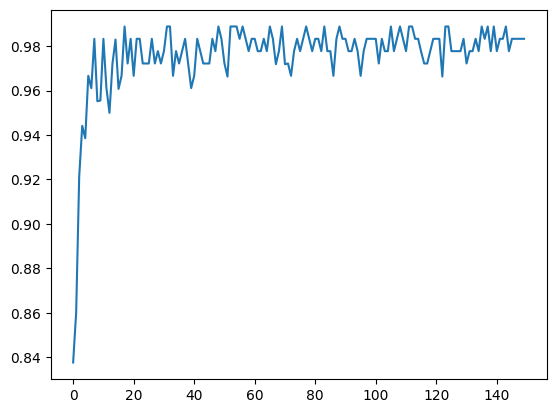

In [18]:
superpa = []

for i in range(150):
    rfc = RandomForestClassifier(n_estimators=i+1, n_jobs=-1)
    rfc_s = cross_val_score(rfc, wine.data, wine.target, cv=10).mean()
    
    superpa.append(rfc_s)
    
print(max(superpa), superpa.index(max(superpa))+1)

plt.plot(superpa, label="Random Forest")
plt.show()

In [30]:
# random_state的设置
rfc= RandomForestClassifier(n_estimators=10, random_state=42)

rfc = rfc.fit(Xtrain, Ytrain)
for i in range(10):
    
    print(rfc.estimators_[i].random_state)

1608637542
1273642419
1935803228
787846414
996406378
1201263687
423734972
415968276
670094950
1914837113


In [31]:
rfc_1 = RandomForestClassifier(n_estimators=25, oob_score=True)
rfc_1 = rfc_1.fit(Xtrain, Ytrain)

In [39]:
rfc_1.estimators_

[DecisionTreeClassifier(max_features='sqrt', random_state=1771714708),
 DecisionTreeClassifier(max_features='sqrt', random_state=1303549768),
 DecisionTreeClassifier(max_features='sqrt', random_state=95629362),
 DecisionTreeClassifier(max_features='sqrt', random_state=2118149166),
 DecisionTreeClassifier(max_features='sqrt', random_state=137497353),
 DecisionTreeClassifier(max_features='sqrt', random_state=546462113),
 DecisionTreeClassifier(max_features='sqrt', random_state=1114655446),
 DecisionTreeClassifier(max_features='sqrt', random_state=550931275),
 DecisionTreeClassifier(max_features='sqrt', random_state=663876656),
 DecisionTreeClassifier(max_features='sqrt', random_state=1482025543),
 DecisionTreeClassifier(max_features='sqrt', random_state=199173431),
 DecisionTreeClassifier(max_features='sqrt', random_state=1628097504),
 DecisionTreeClassifier(max_features='sqrt', random_state=1028074512),
 DecisionTreeClassifier(max_features='sqrt', random_state=1336310490),
 DecisionTree

In [33]:
# 袋外数据的测试结果
rfc_1.oob_score_

0.9435483870967742

In [35]:
# 特征的重要性
rfc.feature_importances_

array([0.07057422, 0.04120711, 0.01367523, 0.00863721, 0.05430537,
       0.1171108 , 0.23208661, 0.00203972, 0.03360061, 0.11844335,
       0.02529011, 0.10329808, 0.17973158])

In [36]:
rfc.apply(Xtest)

array([[11,  8,  8,  7,  8,  9, 13,  4, 12,  2],
       [11,  8,  8,  7,  8,  9, 13,  7, 12,  2],
       [13, 16,  8, 10,  8,  9, 16,  4, 12,  2],
       [15, 16, 16, 14, 14, 16, 16, 13, 23, 16],
       [15,  8,  8,  7,  8, 16, 13,  4,  6,  2],
       [ 9,  8, 16,  7,  6, 11, 13, 13, 23, 16],
       [11, 11,  8,  7,  8,  9, 16,  7, 12,  2],
       [15, 16, 16, 13, 11, 16, 16, 13, 23, 16],
       [11, 11, 13,  7,  8,  7, 15,  9, 12,  2],
       [ 9,  8,  2,  4,  4, 11, 13,  6,  7, 12],
       [11, 13, 13, 13,  8,  9, 16, 12, 12,  2],
       [ 6,  4,  2,  4,  4, 11, 13,  6, 22, 12],
       [15, 16, 16, 14, 14, 16, 16, 13, 24, 16],
       [11, 13, 13, 14, 14, 15, 16, 12, 24,  9],
       [17, 16, 16, 11, 14, 16, 16, 13, 24,  6],
       [ 8,  4,  5,  7,  4,  9, 13,  3,  4,  2],
       [11, 13, 13, 13,  8,  9, 15, 12, 12,  2],
       [11, 10, 11,  7,  8,  9, 15,  9, 12,  2],
       [15, 16, 16, 11, 12,  9, 16, 13, 12, 16],
       [11, 13, 11, 10,  8,  9, 15,  9, 12,  2],
       [15, 16,  8, 

In [37]:
rfc.predict(Xtest)

array([1, 1, 1, 0, 1, 0, 1, 0, 1, 2, 1, 2, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 2, 2, 0, 1, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 1, 1, 1, 0, 1, 2,
       2, 1, 2, 1, 2, 1, 0, 1, 2, 2])

In [38]:
rfc.predict_proba(Xtest)

array([[0. , 1. , 0. ],
       [0. , 1. , 0. ],
       [0.2, 0.8, 0. ],
       [1. , 0. , 0. ],
       [0.2, 0.7, 0.1],
       [0.4, 0.3, 0.3],
       [0.2, 0.8, 0. ],
       [0.9, 0.1, 0. ],
       [0.1, 0.9, 0. ],
       [0. , 0.3, 0.7],
       [0.1, 0.9, 0. ],
       [0. , 0.1, 0.9],
       [1. , 0. , 0. ],
       [0.4, 0.6, 0. ],
       [1. , 0. , 0. ],
       [0. , 0.6, 0.4],
       [0. , 1. , 0. ],
       [0. , 1. , 0. ],
       [0.7, 0.3, 0. ],
       [0. , 1. , 0. ],
       [0.7, 0.3, 0. ],
       [0. , 1. , 0. ],
       [0. , 1. , 0. ],
       [0. , 1. , 0. ],
       [0. , 0.2, 0.8],
       [0.2, 0.1, 0.7],
       [1. , 0. , 0. ],
       [0. , 1. , 0. ],
       [0. , 0. , 1. ],
       [0.1, 0.4, 0.5],
       [0.1, 0.1, 0.8],
       [0. , 0.2, 0.8],
       [0.3, 0.2, 0.5],
       [0.1, 0.1, 0.8],
       [0. , 0.9, 0.1],
       [0. , 0.1, 0.9],
       [0.1, 0.8, 0.1],
       [0. , 0.1, 0.9],
       [0. , 1. , 0. ],
       [0.1, 0.8, 0.1],
       [0. , 0.7, 0.3],
       [1. , 0. 

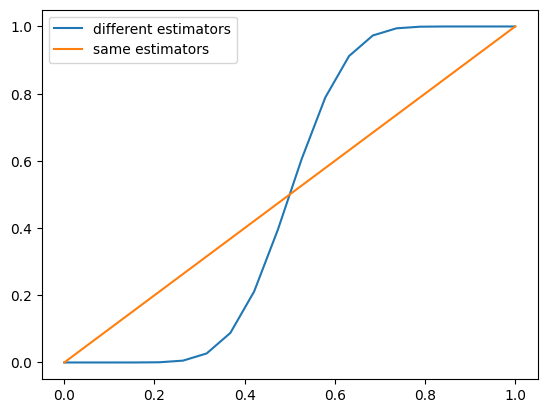

In [7]:
import numpy as np
from math import comb

x = np.linspace(0, 1, 20)
y = []

for epsilon in np.linspace(0, 1, 20):
    e = np.array([comb(25, i) * (epsilon**i) * (1-epsilon) ** (25 - i) for i in range(13,26)]).sum()
    
    y.append(e)
    
    
plt.plot(x,y, label="different estimators")
plt.plot(x,x, label="same estimators")
plt.legend()
plt.show()

In [8]:
import sklearn
sklearn.metrics.get_scorer_names()

['accuracy',
 'adjusted_mutual_info_score',
 'adjusted_rand_score',
 'average_precision',
 'balanced_accuracy',
 'completeness_score',
 'explained_variance',
 'f1',
 'f1_macro',
 'f1_micro',
 'f1_samples',
 'f1_weighted',
 'fowlkes_mallows_score',
 'homogeneity_score',
 'jaccard',
 'jaccard_macro',
 'jaccard_micro',
 'jaccard_samples',
 'jaccard_weighted',
 'matthews_corrcoef',
 'max_error',
 'mutual_info_score',
 'neg_brier_score',
 'neg_log_loss',
 'neg_mean_absolute_error',
 'neg_mean_absolute_percentage_error',
 'neg_mean_gamma_deviance',
 'neg_mean_poisson_deviance',
 'neg_mean_squared_error',
 'neg_mean_squared_log_error',
 'neg_median_absolute_error',
 'neg_negative_likelihood_ratio',
 'neg_root_mean_squared_error',
 'normalized_mutual_info_score',
 'positive_likelihood_ratio',
 'precision',
 'precision_macro',
 'precision_micro',
 'precision_samples',
 'precision_weighted',
 'r2',
 'rand_score',
 'recall',
 'recall_macro',
 'recall_micro',
 'recall_samples',
 'recall_weighted',

### 缺失值填补

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer

In [11]:
data = fetch_california_housing()
data.data.shape

(20640, 8)

In [13]:
X_full, Y_full = data.data, data.target
# n_samples = len(X_full)
# n_features = len(X_full[1])
n_samples, n_features = X_full.shape
print(n_samples, n_features)

20640 8


In [14]:
rng = np.random.RandomState(42)
missing_rate = 0.2
n_missing_samples = int(n_samples * missing_rate)
print(n_missing_samples)

4128


In [15]:
X_missing, Y_missing = X_full.copy(), Y_full.copy()
X_missing


array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]])

In [16]:
mask = np.random.random(X_missing.shape) < missing_rate
mask

array([[False, False, False, ..., False,  True,  True],
       [False,  True, False, ..., False, False, False],
       [False, False, False, ..., False,  True, False],
       ...,
       [ True, False, False, ...,  True, False, False],
       [False,  True, False, ..., False,  True, False],
       [False, False, False, ..., False, False, False]])

In [17]:
X_missing[mask] = np.nan
X_missing

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
                  nan,           nan],
       [   8.3014    ,           nan,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
                  nan, -122.24      ],
       ...,
       [          nan,   17.        ,    5.20554273, ...,           nan,
          39.43      , -121.22      ],
       [   1.8672    ,           nan,    5.32951289, ...,    2.12320917,
                  nan, -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]])

In [ ]:
# 用均值填充
imp_mean = SimpleImputer(missing_values=np.nan, strategy="mean")
X_missing_mean = imp_mean.fit_transform(X_missing)
X_missing_mean

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          35.62846342, -119.57393078],
       [   8.3014    ,   28.618538  ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          35.62846342, -122.24      ],
       ...,
       [   3.85895229,   17.        ,    5.20554273, ...,    3.10568176,
          39.43      , -121.22      ],
       [   1.8672    ,   28.618538  ,    5.32951289, ...,    2.12320917,
          35.62846342, -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]])

In [20]:
pd.DataFrame(X_missing_mean).isnull().sum()

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
dtype: int64

In [ ]:
# 用0填充
imp_0 = SimpleImputer(missing_values=np.nan, strategy="constant", fill_value=0)
X_missing_0 = imp_0.fit_transform(X_missing)
X_missing_0

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           0.        ,    0.        ],
       [   8.3014    ,    0.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           0.        , -122.24      ],
       ...,
       [   0.        ,   17.        ,    5.20554273, ...,    0.        ,
          39.43      , -121.22      ],
       [   1.8672    ,    0.        ,    5.32951289, ...,    2.12320917,
           0.        , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]])

---

In [40]:
X_missing = pd.DataFrame(X_missing)
X_missing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       16605 non-null  float64
 1   1       16539 non-null  float64
 2   2       16387 non-null  float64
 3   3       16504 non-null  float64
 4   4       16529 non-null  float64
 5   5       16488 non-null  float64
 6   6       16348 non-null  float64
 7   7       16498 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [24]:
X_missing.isnull().sum()

0    4035
1    4101
2    4253
3    4136
4    4111
5    4152
6    4292
7    4142
dtype: int64

In [ ]:
# 如果只对缺失值的数量排序，那么无法记录索引信息
np.sort(X_missing.isnull().sum())

array([4035, 4101, 4111, 4136, 4142, 4152, 4253, 4292], dtype=int64)

In [ ]:
# 根据缺失值数量对索引进行排序
np.argsort(X_missing.isnull().sum())

0    0
1    1
2    4
3    3
4    7
5    5
6    2
7    6
dtype: int64

In [ ]:
# 按照这个优先级进行缺失值填补
sorted_index = np.argsort(X_missing.isnull().sum()).values
sorted_index

array([0, 1, 4, 3, 7, 5, 2, 6], dtype=int64)

In [41]:
X_missing_reg = X_missing.copy()
X_missing_reg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       16605 non-null  float64
 1   1       16539 non-null  float64
 2   2       16387 non-null  float64
 3   3       16504 non-null  float64
 4   4       16529 non-null  float64
 5   5       16488 non-null  float64
 6   6       16348 non-null  float64
 7   7       16498 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [42]:
print(X_missing_reg.shape)
for i in sorted_index:
    print(i)
    # 每个i是需要填充缺失值的列
    
    # 需要取出非填充列和标签列组成特征矩阵
    # 填充列作为 Y
    
    # 需要填充的列
    fillc = X_missing_reg.iloc[:, i]
    print(fillc.info())
    
    # 构造新的特征矩阵
    df = pd.concat([pd.DataFrame(X_missing_reg.iloc[:, X_missing_reg.columns != i]), pd.DataFrame(Y_missing)], axis=1)
    
    # 特征矩阵中的缺失值用0填充
    df = SimpleImputer(missing_values=np.nan, strategy="constant", fill_value=0).fit_transform(df)
    
    # 构造训练和测试集
    Ytrain = fillc[fillc.notnull()]
    Ytest = fillc[fillc.isnull()]
    
    Xtrain = df[fillc.notnull()]
    Xtest = df[fillc.isnull()]
    print(Xtrain.shape, Xtest.shape)
    
    rfc = RandomForestRegressor(n_estimators=25, random_state=42)
    rfc.fit(Xtrain, Ytrain)
    Ypredict = rfc.predict(Xtest)
    
    X_missing_reg.iloc[X_missing_reg.iloc[:,i].isnull(), i] = Ypredict
    

X_missing_reg.isnull().sum()

(20640, 8)
0
<class 'pandas.core.series.Series'>
RangeIndex: 20640 entries, 0 to 20639
Series name: 0
Non-Null Count  Dtype  
--------------  -----  
16605 non-null  float64
dtypes: float64(1)
memory usage: 161.4 KB
None
(16605, 8) (4035, 8)
1
<class 'pandas.core.series.Series'>
RangeIndex: 20640 entries, 0 to 20639
Series name: 1
Non-Null Count  Dtype  
--------------  -----  
16539 non-null  float64
dtypes: float64(1)
memory usage: 161.4 KB
None
(16539, 8) (4101, 8)
4
<class 'pandas.core.series.Series'>
RangeIndex: 20640 entries, 0 to 20639
Series name: 4
Non-Null Count  Dtype  
--------------  -----  
16529 non-null  float64
dtypes: float64(1)
memory usage: 161.4 KB
None
(16529, 8) (4111, 8)
3
<class 'pandas.core.series.Series'>
RangeIndex: 20640 entries, 0 to 20639
Series name: 3
Non-Null Count  Dtype  
--------------  -----  
16504 non-null  float64
dtypes: float64(1)
memory usage: 161.4 KB
None
(16504, 8) (4136, 8)
7
<class 'pandas.core.series.Series'>
RangeIndex: 20640 entries, 

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
dtype: int64

In [43]:
X_missing_reg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       20640 non-null  float64
 1   1       20640 non-null  float64
 2   2       20640 non-null  float64
 3   3       20640 non-null  float64
 4   4       20640 non-null  float64
 5   5       20640 non-null  float64
 6   6       20640 non-null  float64
 7   7       20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [44]:
X_missing_reg.head()

,0,1,2,3,4,5,6,7
0,8.3252,41.0,6.984127,1.023810,850.08,2.555556,34.7484,-119.9932
1,8.3014,41.0,6.238137,0.971880,868.24,2.109842,37.8600,-122.2200
2,7.2574,52.0,8.288136,1.073446,819.44,2.802260,37.8144,-122.2400
3,5.6431,52.0,5.817352,1.073059,558.00,2.547945,37.8500,-122.2500
4,3.8462,52.0,6.281853,1.081081,660.00,2.498263,37.8500,-122.2716


In [49]:
X = [
    X_full, 
    X_missing_mean, 
    X_missing_0, 
    X_missing_reg
    ]
mse = []

for x in X:
    print(1)
    estimator = RandomForestRegressor(random_state=42, n_estimators=25)
    print(2)
    score = cross_val_score(estimator, x, Y_full, cv=5, scoring="neg_mean_squared_error").mean()
    print(3)
    mse.append(-score)
    
print(mse)

1
2
3
1
2
3
1
2
3
1
2
3
[0.43806512280718524, 0.6413588434404704, 0.6443833355993351, 0.370466853635683]


可以发现效果会更好

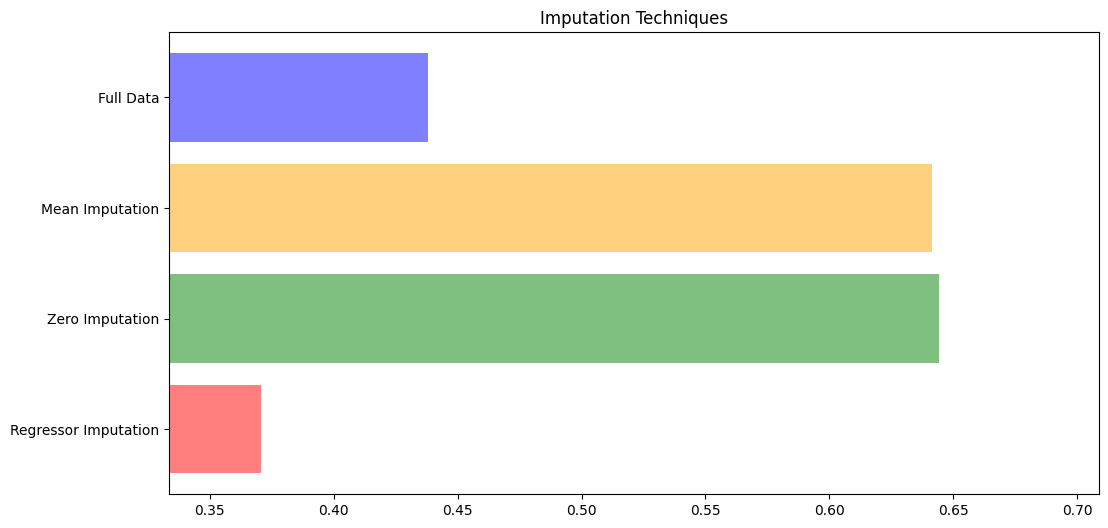

In [51]:
technique_labels = [
    "Full Data",
    "Mean Imputation",
    "Zero Imputation",
    "Regressor Imputation"
]

colors = [
    "blue",
    "orange",
    "green",
    "red"
]

plt.figure(figsize=(12,6))
ax = plt.subplot(111)

for i in np.arange(len(mse)):
    ax.barh(i, mse[i], color=colors[i], alpha=0.5, align="center")
    
ax.set_title("Imputation Techniques")
ax.set_xlim(left=np.min(mse) * 0.9, right=np.max(mse) * 1.1)
ax.set_yticks(np.arange(len(mse)))
ax.set_yticklabels(technique_labels)
ax.invert_yaxis()
plt.show()